# Linear Elasticity in 2D

This example demonstrates the solution of a simple plane stress problem using LowLevelFEM.

The problem is solved in two different ways:

1. Using the built-in elasticity solver.
2. Using the weak-form DSL interface.

The results are compared with the analytical solution.

In [23]:
using LowLevelFEM

## Geometry and Material

A unit square domain is discretized using a structured mesh.

The material is assumed to be homogeneous, isotropic, and linearly elastic under plane stress conditions.

In [24]:
structured_rect_mesh()

mat = Material("body", E=2e5, ν=0.3)
prob = Problem([mat], type=:PlaneStress);

## Boundary Conditions and Loading

The left edge is fixed in the horizontal direction, and the bottom edge is fixed in the vertical direction.

A uniform tensile load is applied to the right edge.

In [25]:
ld = load("right", fx=1)

bc1 = displacementConstraint("left", ux=0)
bc2 = displacementConstraint("bottom", uy=0);

## Solution Using the Built-in Elasticity Solver

In [26]:
u = solveDisplacement(prob, load=[ld], support=[bc1, bc2]);

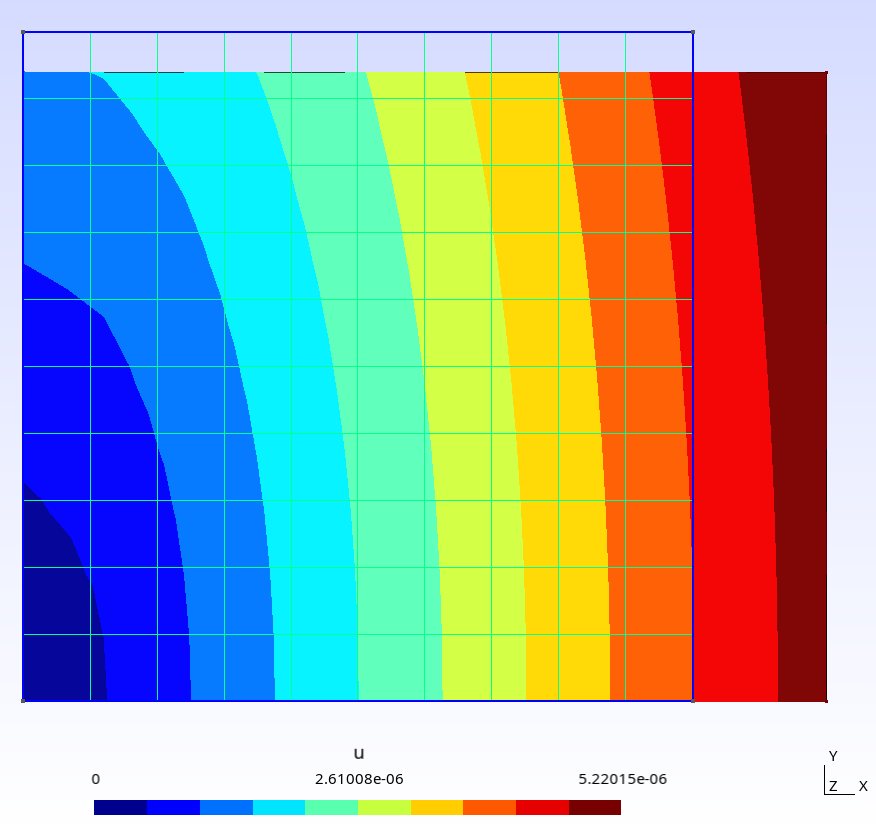

The strain and stress fields are computed from the displacement solution.

In [27]:
ε = solveStrain(u)
σ = solveStress(u);

In [28]:
probe(u, 1, 1, 0)

2-element Vector{Float64}:
  5.0e-6
 -1.5e-6

In [29]:
probe(σ, 0.5, 0.5, 0)

3×3 Matrix{Float64}:
 1.0   0.0  0.0
 0.0  -0.0  0.0
 0.0   0.0  0.0

## Post-processing

Displacements, strains, and stresses can be visualized directly in the Gmsh post-processor.

In [30]:
showDoFResults(u, name="u vec", visible=true)
showDoFResults(u, name="u", factor=4e4)
showDoFResults(u, :x, name="ux")
showDoFResults(u, :y, name="uy")

showStrainResults(ε, :x, name="εx")
showStrainResults(ε, :y, name="εy")
showStrainResults(ε, :xy, name="γxy")

showStressResults(σ, name="σ_eqv")
showStressResults(σ, name="σ_eqv", smooth=true)
showStressResults(σ, :x, name="σx")
showStressResults(σ, :y, name="σy")
showStressResults(σ, :xy, name="τxy");

# The Same Problem Using the DSL Interface

The following section solves exactly the same problem by assembling the weak form directly.

This approach provides greater flexibility and is particularly useful when implementing custom formulations.

In [31]:
Pu = Problem([mat], type=:VectorField, dim=2, field=:u, rhs_field=:f);

## Constitutive Matrix

For plane stress conditions, the constitutive matrix is

$$
D=\frac{E}{1-\nu^2}
\begin{bmatrix}
1 & \nu & 0\\
\nu & 1 & 0\\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}
$$

In [32]:
E = mat.E
ν = mat.ν
D = E / (1 - ν^2) * [1 ν 0; ν 1 0; 0 0 (1-ν)/2]

3×3 Matrix{Float64}:
     2.1978e5  65934.1           0.0
 65934.1           2.1978e5      0.0
     0.0           0.0       76923.1

## Weak Form Assembly

The stiffness matrix is assembled directly from the weak form

$$
K=\int_{\Omega}\varepsilon^T D \varepsilon\, d\Omega
$$

using the symbolic operators provided by LowLevelFEM.

In [33]:
K = ∫(SymGrad(Pu) ⋅ D ⋅ SymGrad(Pu));

In [34]:
f = ∫(Pu ⋅ [1, 0], Γ="right");

In [35]:
bc3 = BoundaryCondition("left", ux=0)
bc4 = BoundaryCondition("bottom", uy=0);

## Solution of the Discrete System

In [36]:
u2 = solveField(K, f, support=[bc3, bc4]);

## Post-processing of the DSL Solution

The strain and stress components are reconstructed explicitly from the displacement field.

In [37]:
εx = ∂x(u2[1])
εy = ∂y(u2[2])
γxy = ∂y(u2[1]) + ∂x(u2[2])

ε2 = [εx, εy, γxy];

In [38]:
σ2 = D * ε2;

In [39]:
σx = σ2[1]
σy = σ2[2]
τxy = σ2[3];

In [40]:
showDoFResults(u2, name="u (DSL)")

showElementResults(εx, name="εx (DSL)")
showElementResults(εy, name="εy (DSL)")
showElementResults(γxy, name="γxy (DSL)")

σeqv = √(((σx - σy) * (σx - σy) + σx * σx + σy * σy + 6τxy * τxy) / 2)

showElementResults(σeqv, name="σ_eqv (DSL)")
showElementResults(σx, name="σx (DSL)")
showElementResults(σy, name="σy (DSL)")
showElementResults(τxy, name="τxy (DSL)");

# Comparison with the Analytical Solution

For this simple uniaxial tension problem, the exact solution is known.

The displacement at the right edge can therefore be compared directly with the finite element results.

In [41]:
σx_ex = 1
εx_ex = σx_ex / E
u_max = εx_ex * 1

5.0e-6

In [42]:
probe(u[1], 1, 1, 0)

5.0e-6

In [43]:
probe(u2[1], 1, 1, 0)

5.0e-6

## Open the Post-processor

Open the Gmsh post-processor to inspect the computed fields.

In [44]:
openPostProcessor()

## Summary

This example demonstrated:

- solution of a plane stress problem using the built-in elasticity solver,
- solution of the same problem using the weak-form DSL,
- computation of strains and stresses,
- comparison with an analytical solution.

Both approaches produce the same result, while the DSL formulation provides direct access to the weak form.